In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from sklearn import metrics

In [2]:
IMAGE_H = 256
IMAGE_W = 256
BATCH_SIZE = 32
channels = 3
epochs= 50
SEED = 123

In [3]:
import os

In [5]:
base_dir = os.path.abspath(r'E:\ORAL_CANCER\oral_datasets\SMOTE_AUGMENTATION')

In [6]:
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [7]:
print("Training directory:", train_dir)
print("Validation directory:", val_dir)
print("Test directory:", test_dir)

Training directory: E:\ORAL_CANCER\oral_datasets\SMOTE_AUGMENTATION\train
Validation directory: E:\ORAL_CANCER\oral_datasets\SMOTE_AUGMENTATION\val
Test directory: E:\ORAL_CANCER\oral_datasets\SMOTE_AUGMENTATION\test


In [8]:
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    shuffle=True,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE,
    seed=SEED
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    shuffle=False,
    image_size=(IMAGE_H, IMAGE_W),
    batch_size=BATCH_SIZE
)

# ✅ Save class names BEFORE any transformation
class_names = test_dataset.class_names
print("Class Names:", class_names)


Found 10040 files belonging to 2 classes.
Found 104 files belonging to 2 classes.
Found 106 files belonging to 2 classes.
Class Names: ['400x Normal Oral Cavity Histopathological Images', '400x OSCC Histopathological Images']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

In [10]:
from tensorflow.keras.applications.vgg19 import VGG19

In [11]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten,Dropout
from tensorflow.keras.models import Model

In [12]:
IMAGE_SIZE = [256,256]
vgg = VGG19(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

In [13]:
for layer in vgg.layers:
    layer.trainable = False

In [14]:
from tensorflow.keras.layers import Input, Lambda, Dense, Flatten,Dropout
x = Flatten()(vgg.output)

prediction = Dense(2, activation='softmax')(x)

In [15]:
from tensorflow.keras.models import Model
model = Model(inputs=vgg.input, outputs=prediction)

# view the structure of the model
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 block1_conv1 (Conv2D)       (None, 256, 256, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 256, 256, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 128, 128, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 128, 128, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 128, 128, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 64, 64, 128)       0     

In [16]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)


In [17]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [18]:
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

In [19]:
history=model.fit(
    train_dataset,
    epochs=epochs,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_dataset,
)

Epoch 1/50


c:\Users\gaura\anaconda3\envs\my_env\lib\site-packages\keras\backend.py:5582: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


314/314 [==============================] - 168s 458ms/step - loss: 2.2306 - accuracy: 0.7625 - val_loss: 3.8456 - val_accuracy: 0.7500
Epoch 2/50
314/314 [==============================] - 131s 418ms/step - loss: 0.6582 - accuracy: 0.8907 - val_loss: 3.7361 - val_accuracy: 0.7115
Epoch 3/50
314/314 [==============================] - 130s 415ms/step - loss: 0.2992 - accuracy: 0.9338 - val_loss: 3.4057 - val_accuracy: 0.7404
Epoch 4/50
314/314 [==============================] - 130s 413ms/step - loss: 0.1270 - accuracy: 0.9652 - val_loss: 3.7318 - val_accuracy: 0.7788
Epoch 5/50
314/314 [==============================] - 130s 414ms/step - loss: 0.0817 - accuracy: 0.9764 - val_loss: 3.7752 - val_accuracy: 0.7692
Epoch 6/50
314/314 [==============================] - 132s 422ms/step - loss: 0.0535 - accuracy: 0.9841 - val_loss: 3.4861 - val_accuracy: 0.7212
Epoch 7/50
314/314 [==============================] - 130s 414ms/step - loss: 0.0408 - accuracy: 0.9876 - val_loss: 4.1739 - val_accura

In [20]:
model.evaluate(test_dataset)

4/4 [==============================] - 7s 2s/step - loss: 6.0054 - accuracy: 0.7925


[6.005434513092041, 0.7924528121948242]

In [21]:
acc= history.history['accuracy']
val_acc = history.history['val_accuracy']

loss= history.history['loss']
val_loss = history.history['val_loss']

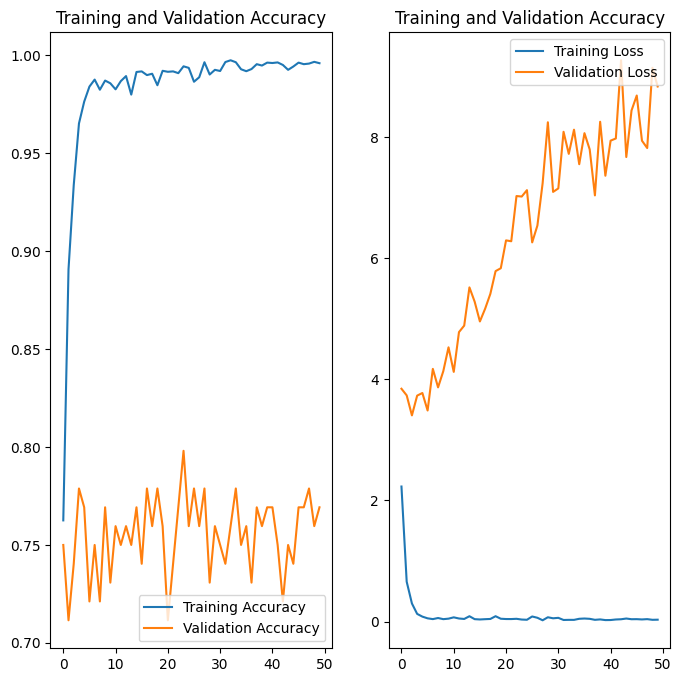

In [22]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(epochs), acc, label='Training Accuracy')
plt.plot(range(epochs), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1,2,2)
plt.plot(range(epochs), loss, label='Training Loss')
plt.plot(range(epochs), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Accuracy')
plt.show()

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
import numpy as np

In [25]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Extract all test images and labels from the test dataset
test_images = []
test_labels = []

for images, labels in test_dataset:
    test_images.append(images)
    test_labels.append(labels)

test_images = tf.concat(test_images, axis=0)
test_labels = tf.concat(test_labels, axis=0)

# Predict using the trained model
y_pred = np.argmax(model.predict(test_images), axis=-1)
y_true = test_labels.numpy()

# Get class names from the dataset
class_names = test_dataset.class_names
print("Class Names:", class_names)

# Print classification report and confusion matrix
print("Classification Report:\n", classification_report(y_true, y_pred, labels=range(len(class_names)), target_names=class_names))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))


4/4 [==============================] - 2s 410ms/step
Class Names: ['400x Normal Oral Cavity Histopathological Images', '400x OSCC Histopathological Images']
Classification Report:
                                                   precision    recall  f1-score   support

400x Normal Oral Cavity Histopathological Images       0.63      0.71      0.67        31
              400x OSCC Histopathological Images       0.87      0.83      0.85        75

                                        accuracy                           0.79       106
                                       macro avg       0.75      0.77      0.76       106
                                    weighted avg       0.80      0.79      0.80       106

Confusion Matrix:
 [[22  9]
 [13 62]]


In [26]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score

# Convert true labels and predicted labels to numpy arrays if they aren't already
y_true = test_labels.numpy() if hasattr(test_labels, 'numpy') else test_labels
y_pred = np.asarray(y_pred)

# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Compute overall metrics
precision = precision_score(y_true, y_pred, average='macro')
recall = recall_score(y_true, y_pred, average='macro')
f1 = f1_score(y_true, y_pred, average='macro')

# Compute specificity for each class
TN = np.zeros(len(class_names))
FP = np.zeros(len(class_names))
for i in range(len(class_names)):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP[i] = np.sum(cm[:, i]) - TP
    TN[i] = np.sum(cm) - (TP + FP[i] + FN)

specificity = np.mean(TN / (TN + FP))

# Display results
print(f"\nOverall Precision (macro):   {precision:.4f}")
print(f"Overall Recall (macro):      {recall:.4f}")
print(f"Overall Specificity (macro): {specificity:.4f}")
print(f"Overall F1 Score (macro):    {f1:.4f}")



Overall Precision (macro):   0.7509
Overall Recall (macro):      0.7682
Overall Specificity (macro): 0.7682
Overall F1 Score (macro):    0.7580


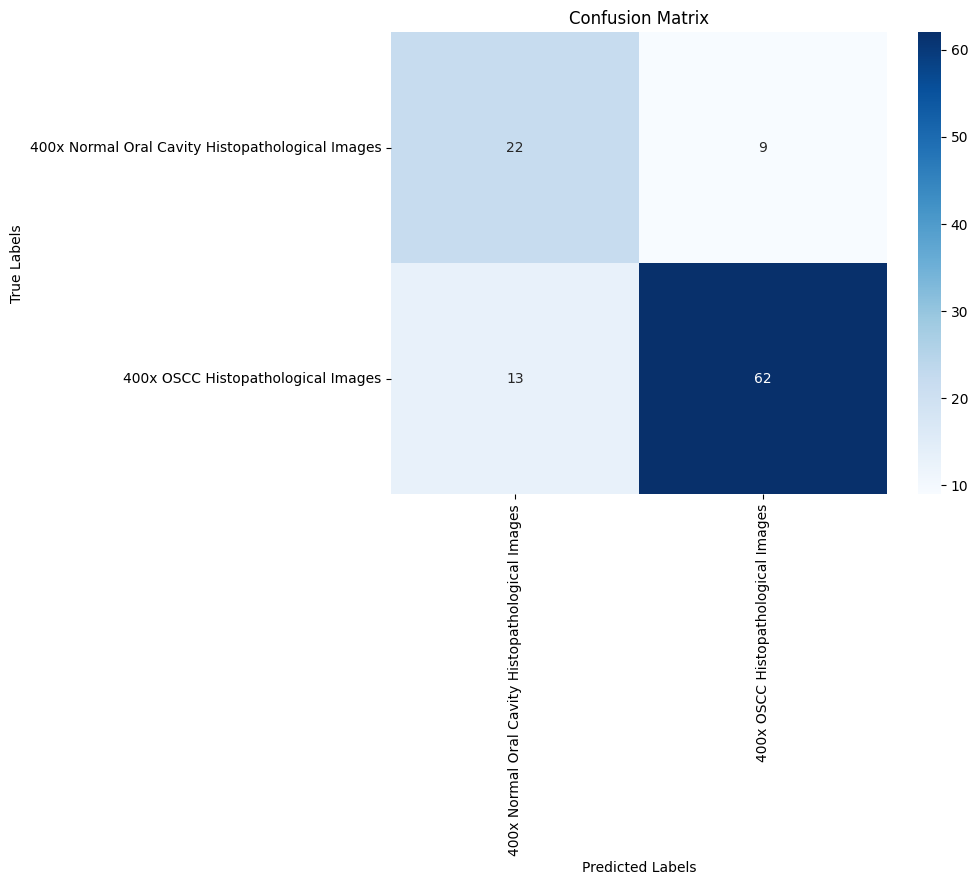

In [27]:
# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

1/1 [==============================] - 0s 37ms/step
AUC Score: 0.8209


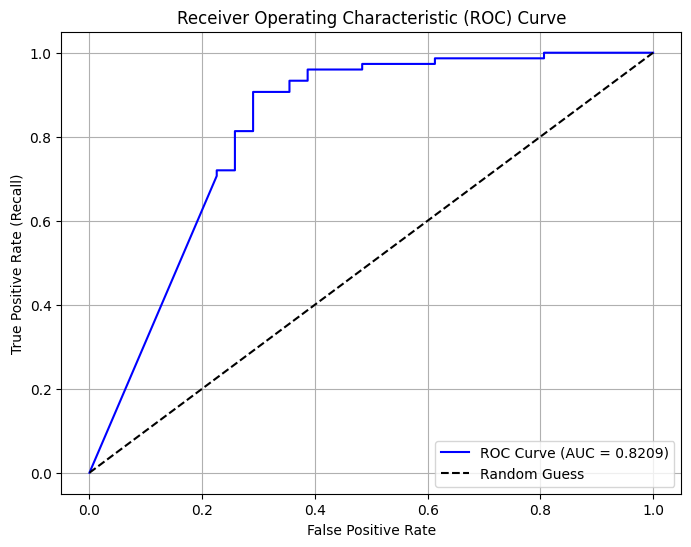

In [28]:
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score

# Collect true labels and predicted scores
y_true = []
y_scores = []

for images, labels in test_dataset:
    preds = model.predict(images)

    # If your model has a sigmoid output for binary classification:
    if preds.shape[1] == 1 or len(preds.shape) == 1:
        preds = preds.flatten()
    else:
        preds = preds[:, 1]  # Use the probability of class 1 in softmax

    y_true.extend(labels.numpy())
    y_scores.extend(preds)

y_true = np.array(y_true)
y_scores = np.array(y_scores)

# ROC Curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_scores)
auc_score = roc_auc_score(y_true, y_scores)
print(f"AUC Score: {auc_score:.4f}")

# Plot ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})", color='blue')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
